In [1]:
import matplotlib.pyplot as plt
import numpy as np
import signac
import gsd.hoomd

In [2]:
project = signac.get_project("/home/stephaniemccallu/scratch/kremer-grest")

<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1040390/697755869.py:33: SyntaxWarning: invalid escape sequence '\p'
  plt.text(1e2, 20, "$\propto t^{0.5}$",fontsize=12, color="black")
/tmp/ipykernel_1040390/697755869.py:34: SyntaxWarning: invalid escape sequence '\p'
  plt.text(1e4, 30, "$\propto t^{0.25}$",fontsize=12, color="red")
/tmp/ipykernel_1040390/697755869.py:35: SyntaxWarning: invalid escape sequence '\p'
  plt.text(1e4, 250, "$\propto t$",fontsize=12, color="black")
/tmp/ipykernel_1040390/697755869.py:12: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence t

Text(0.5, 1.0, 'MSD of center beads, average of 10 seeds')

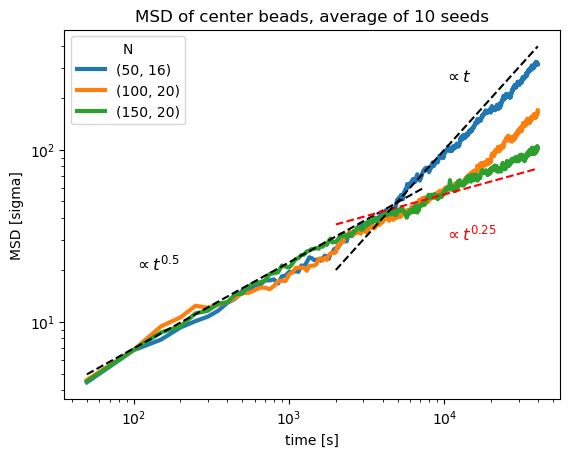

In [26]:
for length, jobs in project.find_jobs().groupby("doc.lengths"):
    msd_avg = []
    msd_list = []
    for job in jobs:
        time = np.load(job.fn("msd_time_mid_c.npy"))
        msd = np.load(job.fn("msd_data_reduced_mid_c.npy"))
        msd_list.append(msd)
    msd_avg = np.zeros((len(msd_list[0])))
    for j in msd_list:
        msd_avg += j
    msd_avg = msd_avg/len(msd_list)
    plt.plot(time[1:], msd_avg[1:], linewidth=3, label=(length,job.doc.num_mols))

plt.plot(
    time[1:150],
    time[1:150]**(0.5)*7e-1,
    color="black",
    linestyle="--"
)

plt.plot(
    time[40:],
    time[40:]**(0.25)*55e-1,
    color="red",
    linestyle="--"
)
plt.plot(
    time[40:],
    time[40:]*1e-2,
    color="black",
    linestyle="--"
)
plt.text(1e2, 20, "$\propto t^{0.5}$",fontsize=12, color="black")
plt.text(1e4, 30, "$\propto t^{0.25}$",fontsize=12, color="red")
plt.text(1e4, 250, "$\propto t$",fontsize=12, color="black")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("time [s]")
plt.ylabel("MSD [sigma]")
plt.legend(title="N")
plt.title("MSD of center beads, average of 10 seeds")

## 65-mer

397


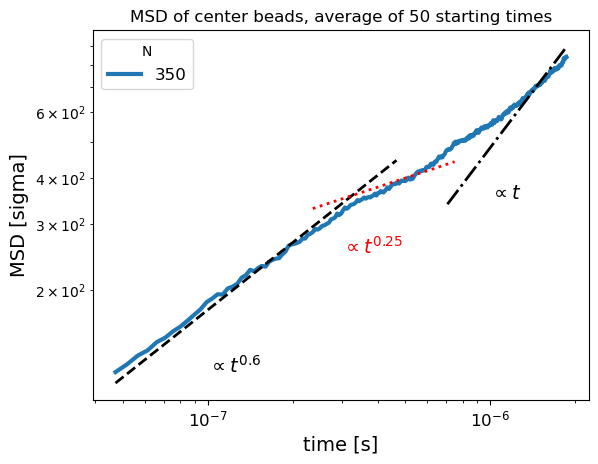

In [17]:
from scipy.optimize import curve_fit
# Define the exponential function to fit
def exp_func(x, a, b):
    return a * np.exp(b * x)
    
for length, jobs in project.find_jobs().groupby("doc.lengths"):
    for job in jobs:
        if length == 350:    
            x = np.load(job.fn("msd_time_bs_50_400.npy"))
            print(len(time))
            y = np.load(job.fn("msd_data_reduced_bs_50_400.npy"))
            plt.plot(x[10:], y[10:], linewidth=3, label=length)


plt.plot(
    time[10:100],
    time[10:100]**(0.6) * 2.8e6,
    color="black",
    linestyle="--",
    linewidth = 2
)

plt.plot(
    time[50:160],
    time[50:160]**(0.25) * 15e3,
    color="red",
    linestyle=":",
    linewidth = 2
)
plt.plot(
    time[150:],
    time[150:] * 4.8e8,
    color="black",
    linestyle="-.",
    linewidth = 2
)
plt.text(1e-7, 120, "$\propto t^{0.6}$",fontsize=14, color="black")
plt.text(3e-7, 250, "$\propto t^{0.25}$",fontsize=14, color="red")
plt.text(10e-7, 350, "$\propto t$",fontsize=14, color="black")


plt.xscale("log")
plt.yscale("log")
plt.xlabel("time [s]",fontsize=14)
plt.ylabel("MSD [sigma]",fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="N",fontsize=12)
plt.title("MSD of center beads, average of 50 starting times")
plt.savefig("350MSD.jpg")

## 100-mer

Text(0.5, 1.0, 'MSD of center beads, average of 3 starting times')

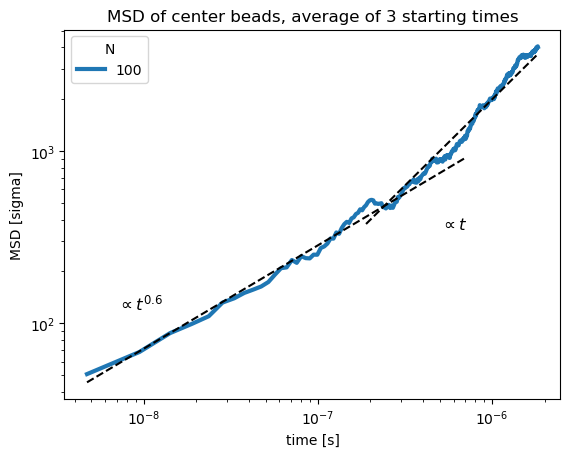

In [23]:
for length, jobs in project.find_jobs({"doc.sampled":True}).groupby("doc.lengths"):
    for job in jobs:
        if length == 100:    
            time = np.load(job.fn("msd_time_bs_3_10.npy"))
            msd_nm_5 = np.load(job.fn("msd_data_reduced_bs_3_10.npy"))
            plt.plot(time[1:], msd_nm_5[1:], linewidth=3, label=length)

plt.plot(
    time[1:150],
    time[1:150]**(0.6) * 4.5e6,
    color="black",
    linestyle="--"
)

'''plt.plot(
    time[1:150],
    time[1:150]**(0.25) * 16e3,
    color="red",
    linestyle="--"
)'''
plt.plot(
    time[40:],
    time[40:] * 2e9,
    color="black",
    linestyle="--"
)
plt.text(0.7e-8, 120, "$\propto t^{0.6}$",fontsize=12, color="black")
#plt.text(0.7e-8, 250, "$\propto t^{0.25}$",fontsize=12, color="red")
plt.text(5e-7, 350, "$\propto t$",fontsize=12, color="black")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("time [s]")
plt.ylabel("MSD [sigma]")
plt.legend(title="N")
plt.title("MSD of center beads, average of 3 starting times")

Text(0.5, 1.0, 'MSD of center beads, average of 3 starting times')

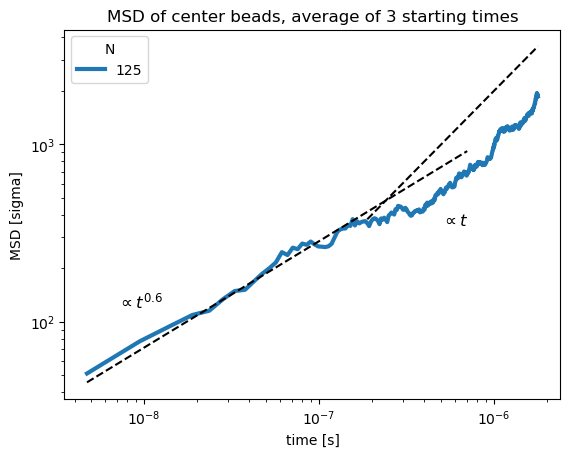

In [19]:
for length, jobs in project.find_jobs().groupby("doc.lengths"):
    for job in jobs:
        if length ==125:    
            time = np.load(job.fn("msd_time_bs_6_20.npy"))
            msd_nm_5 = np.load(job.fn("msd_data_reduced_bs_6_20.npy"))
            plt.plot(time[1:], msd_nm_5[1:], linewidth=3, label=length)

plt.plot(
    time[1:150],
    time[1:150]**(0.6) * 4.5e6,
    color="black",
    linestyle="--"
)

'''plt.plot(
    time[1:150],
    time[1:150]**(0.25) * 16e3,
    color="red",
    linestyle="--"
)'''
plt.plot(
    time[40:],
    time[40:] * 2e9,
    color="black",
    linestyle="--"
)
plt.text(0.7e-8, 120, "$\propto t^{0.6}$",fontsize=12, color="black")
#plt.text(0.7e-8, 250, "$\propto t^{0.25}$",fontsize=12, color="red")
plt.text(5e-7, 350, "$\propto t$",fontsize=12, color="black")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("time [s]")
plt.ylabel("MSD [sigma]")
plt.legend(title="N")
plt.title("MSD of center beads, average of 3 starting times")

## 150-mer

Text(0.5, 1.0, 'MSD of center beads, average of 6 starting times')

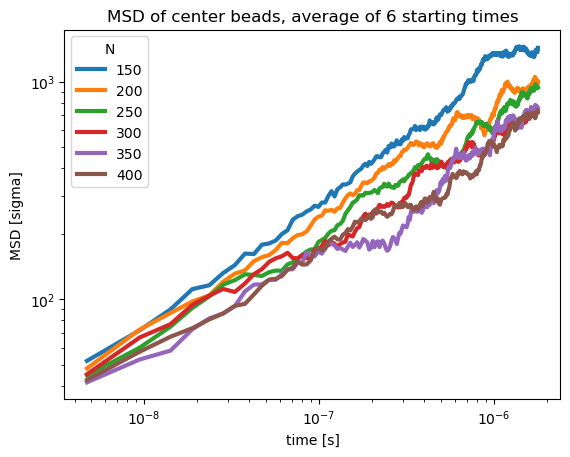

In [8]:
for length, jobs in project.find_jobs({"doc.sampled":True}).groupby("doc.lengths"):
    for job in jobs:
        if length > 100:    
            time = np.load(job.fn("msd_time_bs_6_20.npy"))
            msd_nm_5 = np.load(job.fn("msd_data_reduced_bs_6_20.npy"))
            plt.plot(time[1:], msd_nm_5[1:], linewidth=3, label=length)

'''plt.plot(
    time[1:150],
    time[1:150]**(0.6) * 5e6,
    color="black",
    linestyle="--"
)

plt.plot(
    time[150:399],
    time[150:399]**(0.25) * 4e4,
    color="red",
    linestyle="--"
)

plt.plot(
    time[10:],
    time[10:] * 2e9,
    color="black",
    linestyle="--"
)
plt.text(0.7e-8, 120, "$\propto t^{0.6}$",fontsize=12, color="black")
plt.text(8e-7, 650, "$\propto t^{0.25}$",fontsize=12, color="red")
#plt.text(1e-7, 150, "$\propto t$",fontsize=12, color="black")
'''
plt.xscale("log")
plt.yscale("log")
plt.xlabel("time [s]")
plt.ylabel("MSD [sigma]")
plt.legend(title="N")
plt.title("MSD of center beads, average of 6 starting times")

## 200-mer

Text(0.5, 1.0, 'MSD of center beads, average of 3 starting times')

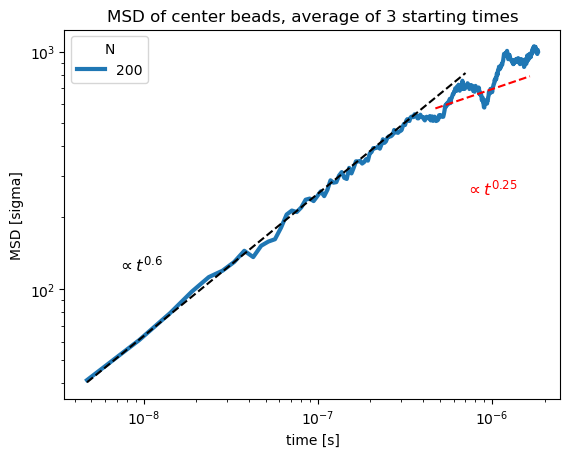

In [44]:
for length, jobs in project.find_jobs({"doc.sampled":True}).groupby("doc.lengths"):
    for job in jobs:
        if length == 200:    
            time = np.load(job.fn("msd_time_bs_3_10.npy"))
            msd_nm_5 = np.load(job.fn("msd_data_reduced_bs_3_10.npy"))
            plt.plot(time[1:], msd_nm_5[1:], linewidth=3, label=length)

plt.plot(
    time[1:150],
    time[1:150]**(0.6) * 4e6,
    color="black",
    linestyle="--"
)

plt.plot(
    time[100:350],
    time[100:350]**(0.25) * 22e3,
    color="red",
    linestyle="--"
)
'''plt.plot(
    time[10:],
    time[10:] * 2e9,
    color="black",
    linestyle="--"
)'''
plt.text(0.7e-8, 120, "$\propto t^{0.6}$",fontsize=12, color="black")
plt.text(0.7e-6, 250, "$\propto t^{0.25}$",fontsize=12, color="red")
#plt.text(1e-7, 150, "$\propto t$",fontsize=12, color="black")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("time [s]")
plt.ylabel("MSD [sigma]")
plt.legend(title="N")
plt.title("MSD of center beads, average of 3 starting times")

## 250-mer

Text(0.5, 1.0, 'MSD of center beads, average of 3 starting times')

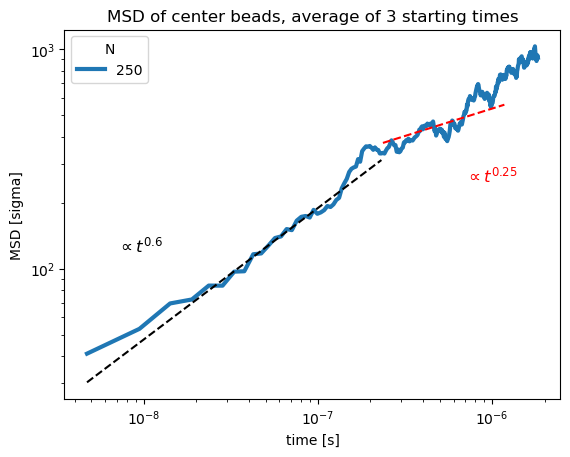

In [53]:
for length, jobs in project.find_jobs({"doc.sampled":True}).groupby("doc.lengths"):
    for job in jobs:
        if length == 250:    
            time = np.load(job.fn("msd_time_bs_3_10.npy"))
            msd_nm_5 = np.load(job.fn("msd_data_reduced_bs_3_10.npy"))
            plt.plot(time[1:], msd_nm_5[1:], linewidth=3, label=length)

plt.plot(
    time[1:50],
    time[1:50]**(0.6) * 3e6,
    color="black",
    linestyle="--"
)

plt.plot(
    time[50:250],
    time[50:250]**(0.25) * 17e3,
    color="red",
    linestyle="--"
)
'''plt.plot(
    time[10:],
    time[10:] * 2e9,
    color="black",
    linestyle="--"
)'''
plt.text(0.7e-8, 120, "$\propto t^{0.6}$",fontsize=12, color="black")
plt.text(0.7e-6, 250, "$\propto t^{0.25}$",fontsize=12, color="red")
#plt.text(1e-7, 150, "$\propto t$",fontsize=12, color="black")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("time [s]")
plt.ylabel("MSD [sigma]")
plt.legend(title="N")
plt.title("MSD of center beads, average of 3 starting times")

## 300-mer

Text(0.5, 1.0, 'MSD of center beads, average of 3 starting times')

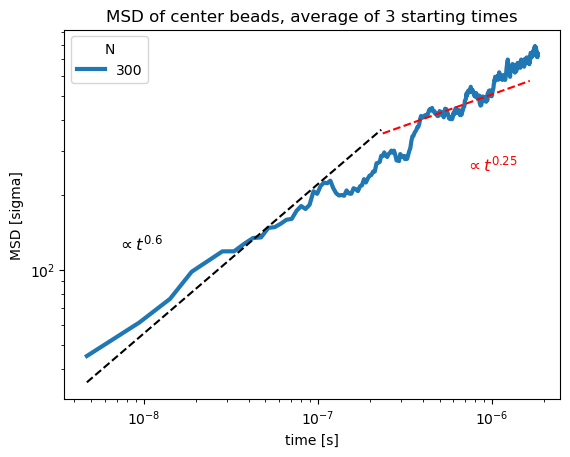

In [66]:
for length, jobs in project.find_jobs({"doc.sampled":True}).groupby("doc.lengths"):
    for job in jobs:
        if length == 300:    
            time = np.load(job.fn("msd_time_bs_3_10.npy"))
            msd_nm_5 = np.load(job.fn("msd_data_reduced_bs_3_10.npy"))
            plt.plot(time[1:], msd_nm_5[1:], linewidth=3, label=length)

plt.plot(
    time[1:50],
    time[1:50]**(0.6) * 3.5e6,
    color="black",
    linestyle="--"
)

plt.plot(
    time[50:350],
    time[50:350]**(0.25) * 16e3,
    color="red",
    linestyle="--"
)
'''plt.plot(
    time[10:],
    time[10:] * 2e9,
    color="black",
    linestyle="--"
)'''
plt.text(0.7e-8, 120, "$\propto t^{0.6}$",fontsize=12, color="black")
plt.text(0.7e-6, 250, "$\propto t^{0.25}$",fontsize=12, color="red")
#plt.text(1e-7, 150, "$\propto t$",fontsize=12, color="black")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("time [s]")
plt.ylabel("MSD [sigma]")
plt.legend(title="N")
plt.title("MSD of center beads, average of 3 starting times")

## 350-mer

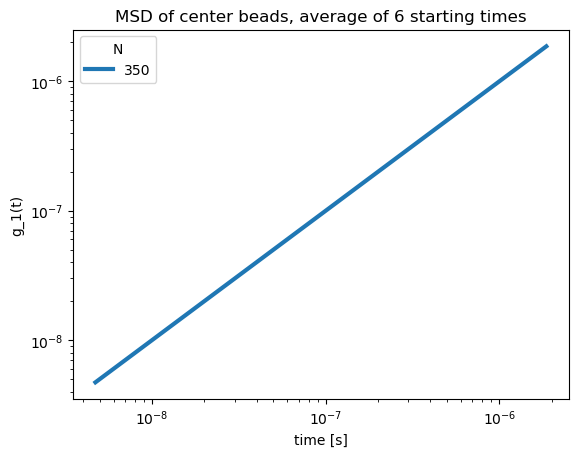

In [6]:
for length, jobs in project.find_jobs({"doc.sampled":True}).groupby("doc.lengths"):
    for job in jobs:
        if length == 350:    
            time = np.load(job.fn("msd_time_bs_50_400.npy"))
            msd_nm_5 = np.load(job.fn("msd_time_bs_50_400.npy"))
            plt.plot(time[1:], msd_nm_5[1:], linewidth=3, label=length)
'''
plt.plot(
    time[1:25],
    time[1:25]**(0.5) * 5.5e4,
    color="black",
    linestyle="--"
)

plt.plot(
    time[20:80],
    time[20:80]**(0.25) * 9e2,
    color="red",
    linestyle="--"
)

plt.plot(
    time[50:200],
    time[50:200]**(0.5) * 4e4,
    color="black",
    linestyle="--"
)
plt.plot(
    time[100:300],
    time[100:300] * 5e7,
    color="black",
    linestyle="--"
)
#plt.text(0.7e-8, 120, "$\propto t^{0.5}$",fontsize=12, color="black")
#plt.text(0.7e-7, 250, "$\propto t^{0.25}$",fontsize=12, color="red")
#plt.text(5e-7, 200, "$\propto t^{0.5}$",fontsize=12, color="black")
#plt.text(1e-6, 350, "$\propto t$",fontsize=12, color="black")
'''
plt.xscale("log")
plt.yscale("log")
plt.xlabel("time [s]")
plt.ylabel("g_1(t)")
plt.legend(title="N")
plt.title("MSD of center beads, average of 6 starting times")
plt.savefig("350 MSD plot.png")

## 400-mer

Text(0.5, 1.0, 'MSD of center beads, average of 3 starting times')

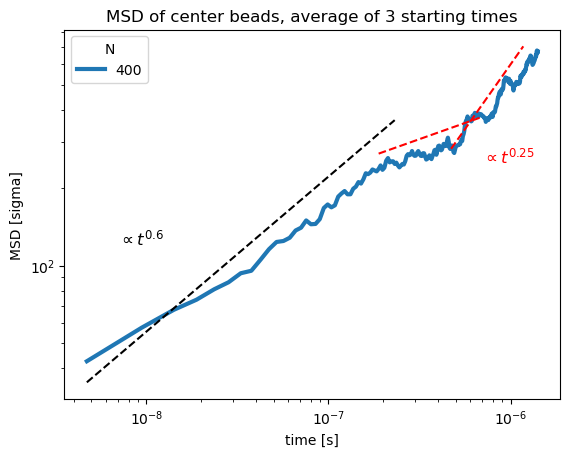

In [14]:
for length, jobs in project.find_jobs({"doc.sampled":True}).groupby("doc.lengths"):
    for job in jobs:
        if length == 400:    
            time = np.load(job.fn("msd_time_bs_50_400.npy"))
            msd_nm_5 = np.load(job.fn("msd_data_reduced_bs_6_20.npy"))
            plt.plot(time[1:300], msd_nm_5[1:300], linewidth=3, label=length)

plt.plot(
    time[1:50],
    time[1:50]**(0.6) * 3.5e6,
    color="black",
    linestyle="--"
)

plt.plot(
    time[40:150],
    time[40:150]**(0.25) * 13e3,
    color="red",
    linestyle="--"
)

plt.plot(
    time[100:250],
    time[100:250] * 6e8,
    color="red",
    linestyle="--"
)
'''plt.plot(
    time[10:],
    time[10:] * 2e9,
    color="black",
    linestyle="--"
)'''
plt.text(0.7e-8, 120, "$\propto t^{0.6}$",fontsize=12, color="black")
plt.text(0.7e-6, 250, "$\propto t^{0.25}$",fontsize=12, color="red")
#plt.text(1e-7, 150, "$\propto t$",fontsize=12, color="black")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("time [s]")
plt.ylabel("MSD [sigma]")
plt.legend(title="N")
plt.title("MSD of center beads, average of 3 starting times")